In [1]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("../data/spam.csv", encoding='latin1')

In [3]:
df.sample(6)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4796,spam,Santa calling! Would your little ones like a c...,NaN,NaN,NaN
1583,ham,"It's cool, let me know before it kicks off aro...",NaN,NaN,NaN
2299,spam,Congrats! 1 year special cinema pass for 2 is ...,NaN,NaN,NaN
1081,ham,Can u get pic msgs to your phone?,NaN,NaN,NaN
485,ham,If we win its really no 1 side for long time.,NaN,NaN,NaN
4904,spam,Warner Village 83118 C Colin Farrell in SWAT t...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

# STEPS
1. Data cleaning
2. EDA
3. Text preprocessing
4. Model Building
5. Improvement

## 1. Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# drop last 3 columns
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [7]:
df.sample(5)

,v1,v2
579,ham,Arngd marriage is while u r walkin unfortuntly...
4649,ham,Finally it has happened..! Aftr decades..! BEE...
575,spam,"You have won ?1,000 cash or a ?2,000 prize! To..."
912,ham,Can't. I feel nauseous. I'm so pissed. I didn'...
1281,ham,Am I the only one who doesn't stalk profiles?


In [8]:
# Renaming the columns

df.rename(columns = {'v1' : 'Target', 'v2' : 'Text'}, inplace = True)
df.sample(5)

,Target,Text
3230,ham,No plm i will come da. On the way.
5032,ham,* Was really good to see you the other day dud...
4282,ham,Science tells that chocolate will melt under t...
410,ham,Come by our room at some point so we can iron ...
5292,spam,Urgent! Please call 09061213237 from landline....


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['Target'] = encoder.fit_transform(df['Target'])

In [11]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Missing Value check
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [13]:
# Ckeck for duplicate values
df.duplicated().sum()

np.int64(403)

In [14]:
# Remove duplicates
df = df.drop_duplicates()

In [15]:
df.shape

(5169, 2)

 ## 2. EDA

In [16]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
# Count number of ham and spam
class_counts = df['Target'].value_counts()
print(class_counts)

Target
0    4516
1     653
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt

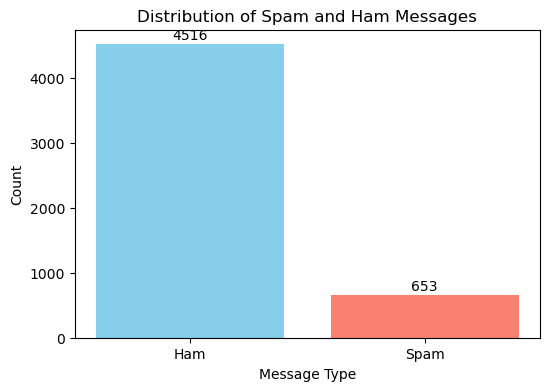

In [19]:
plt.figure(figsize=(6,4))
plt.bar(['Ham', 'Spam'], class_counts.values, color=['skyblue', 'salmon'])

# Add labels and title
plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')

# Add numbers on top of bars
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 30, str(count), ha='center', va='bottom', fontsize=10)

plt.show()


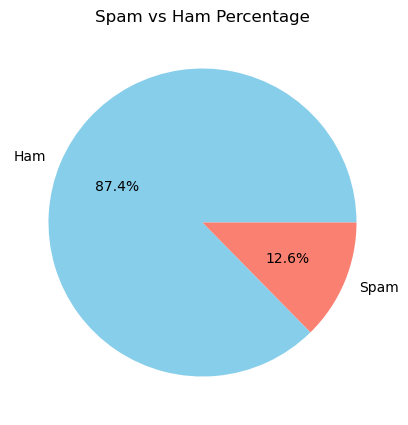

In [20]:
# Plot pie chart
plt.figure(figsize=(5,5))
plt.pie(class_counts.values, 
        labels=['Ham', 'Spam'], 
        autopct='%1.1f%%', 
        colors=['skyblue', 'salmon'])

plt.title('Spam vs Ham Percentage')
plt.show()


In [21]:
# Natural Language Library Toolkit
import nltk

In [22]:
!pip install nltk

In [23]:
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /Users/subham/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [24]:
df = df[['Target', 'Text']].copy()

df['Letter_count'] = df['Text'].apply(len)
df['Word_count'] = df['Text'].apply(lambda x: len(x.split()))
df['Sentence_count'] = df['Text'].apply(lambda x: len(sent_tokenize(str(x))))

print(df.head())

   Target                                               Text  Letter_count  \
0       0  Go until jurong point, crazy.. Available only ...           111   
1       0                      Ok lar... Joking wif u oni...            29   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...           155   
3       0  U dun say so early hor... U c already then say...            49   
4       0  Nah I don't think he goes to usf, he lives aro...            61   

   Word_count  Sentence_count  
0          20               2  
1           6               2  
2          28               2  
3          11               1  
4          13               1  


In [25]:
df[['Letter_count', 'Word_count', 'Sentence_count']].describe()

,Letter_count,Word_count,Sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,1.965564
std,58.236293,11.068488,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,7.000000,1.000000
50%,60.000000,12.000000,1.000000
75%,117.000000,22.000000,2.000000
max,910.000000,171.000000,38.000000


In [26]:
# for spam = 1
df[df['Target'] == 1][['Letter_count', 'Word_count', 'Sentence_count']].describe()

,Letter_count,Word_count,Sentence_count
count,653.000000,653.000000,653.000000
mean,137.891271,23.681470,2.970904
std,30.137753,5.967672,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,22.000000,2.000000
50%,149.000000,25.000000,3.000000
75%,157.000000,28.000000,4.000000
max,224.000000,35.000000,9.000000


In [27]:
# for ham = 0
df[df['Target'] == 0][['Letter_count', 'Word_count', 'Sentence_count']].describe()

,Letter_count,Word_count,Sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,14.134632,1.820195
std,56.358207,11.116240,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,7.000000,1.000000
50%,52.000000,11.000000,1.000000
75%,90.000000,18.000000,2.000000
max,910.000000,171.000000,38.000000


In [28]:
import seaborn as sns

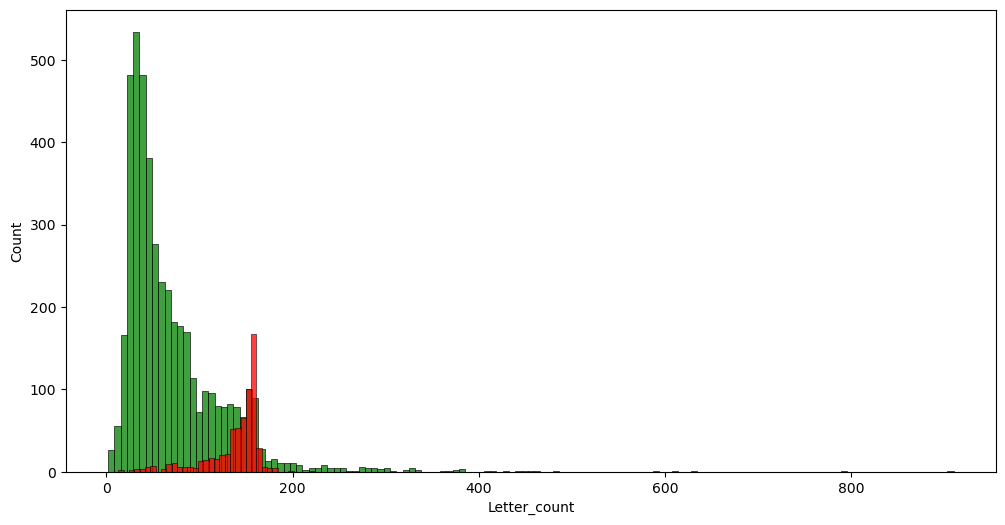

In [29]:
plt.figure(figsize = (12,6))
sns.histplot(df[df['Target'] == 0]['Letter_count'],color = 'green')
sns.histplot(df[df['Target'] == 1]['Letter_count'],color = 'red')

plt.show()

# Most ham messages have less than 100–150 characters.

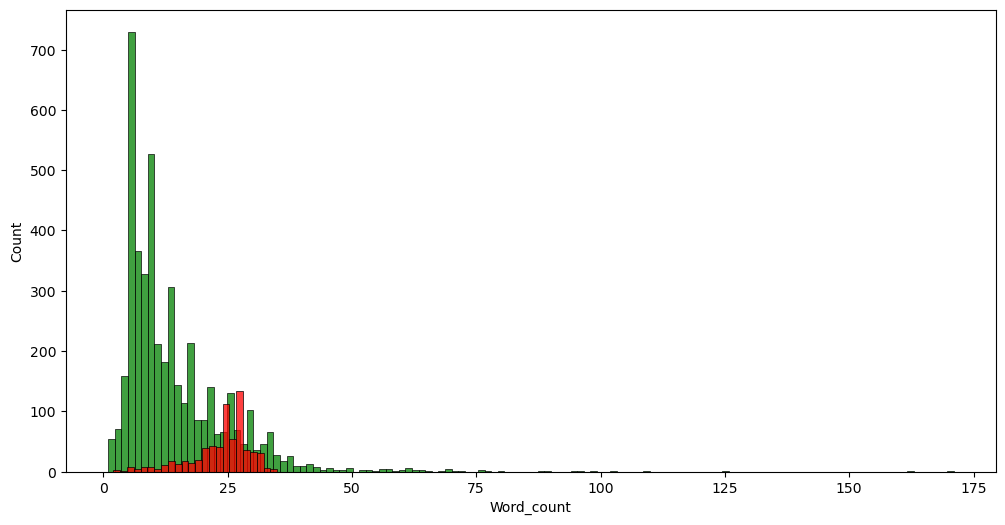

In [30]:
plt.figure(figsize = (12,6))
sns.histplot(df[df['Target'] == 0]['Word_count'],color = 'green')
sns.histplot(df[df['Target'] == 1]['Word_count'],color = 'red')

plt.show()

# Most ham messages have less than 25 words.

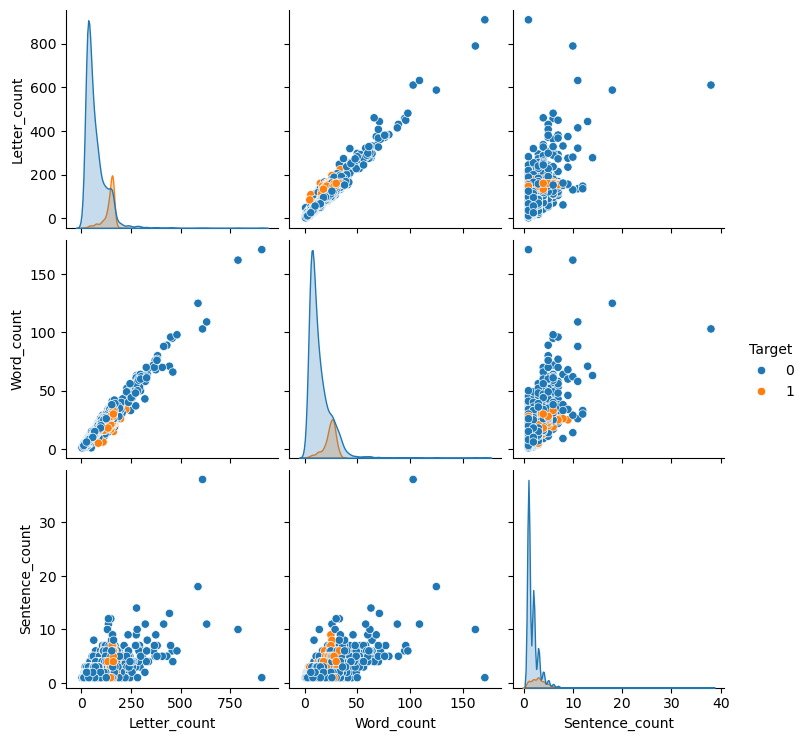

In [31]:
sns.pairplot(df, hue = 'Target')
plt.show()

# Not Too Much helpful here

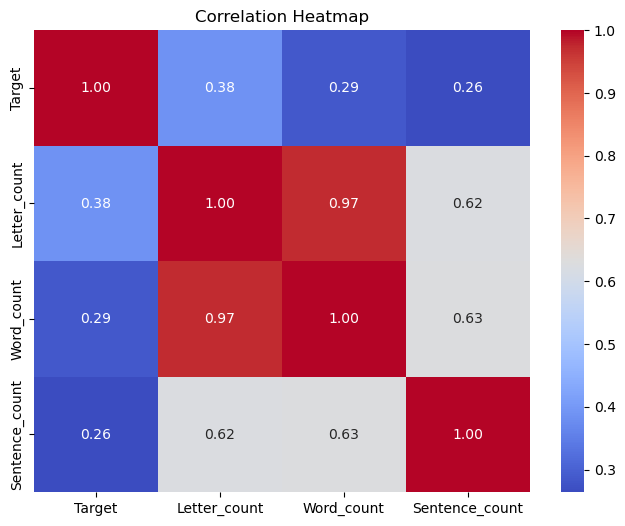

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Target', 'Letter_count', 'Word_count', 'Sentence_count']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


## Data (Text) Preprocessing
- Lower case
- Tokenization
- Removing space characters
- Removing stop words
- Streamming

In [33]:
import nltk
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/subham/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [35]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [36]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Playing')

'play'

In [37]:

def transform_text(text):
    text = text.lower()   # Convert to lowercases
    text = nltk.word_tokenize(text)  # tokenize (split words in a list)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)   # Removes special characters

        text = y[:]
        y.clear()

        for i in text:
            if i not in stopwords.words('english') and i not in string.punctuation:
                y.append(i)

        text = y[:]
        y.clear()
        
        for i in text:
            y.append(ps.stem(i))
    return " ".join(y)

In [38]:
transform_text('Dear Hero,i am leaving to qatar tonite for an apt opportunity.pls do keep in touch at  &lt;EMAIL&gt; ,kerala')

# stopwords : is, Is, it
# Puntuations : ?, .
# Stemming --> eg: 'playing' --> 'play'

'dear hero leav qatar tonit apt keep touch lt email gt kerala'

In [39]:
df['Text'][1009]

'Dear Hero,i am leaving to qatar tonite for an apt opportunity.pls do keep in touch at  &lt;EMAIL&gt; ,kerala'

In [40]:
df['transformed_text'] = df["Text"].apply(transform_text)

In [41]:
df.head()

,Target,Text,Letter_count,Word_count,Sentence_count,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe usf live around though


In [42]:
!pip install wordcloud

In [43]:
from wordcloud import WordCloud
wc = WordCloud(width=1500, height=1500, min_font_size= 10, background_color =  'white')

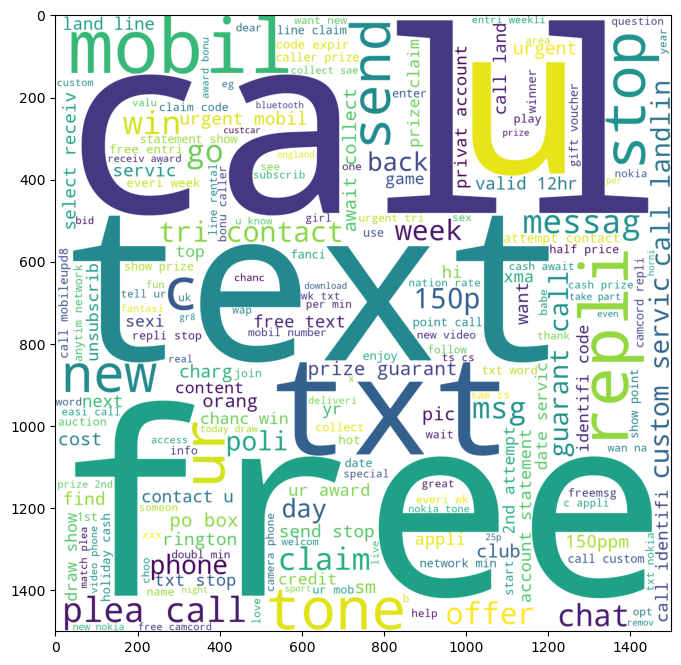

In [44]:
spam_wc = wc.generate(df[df['Target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,8))
plt.imshow(spam_wc)

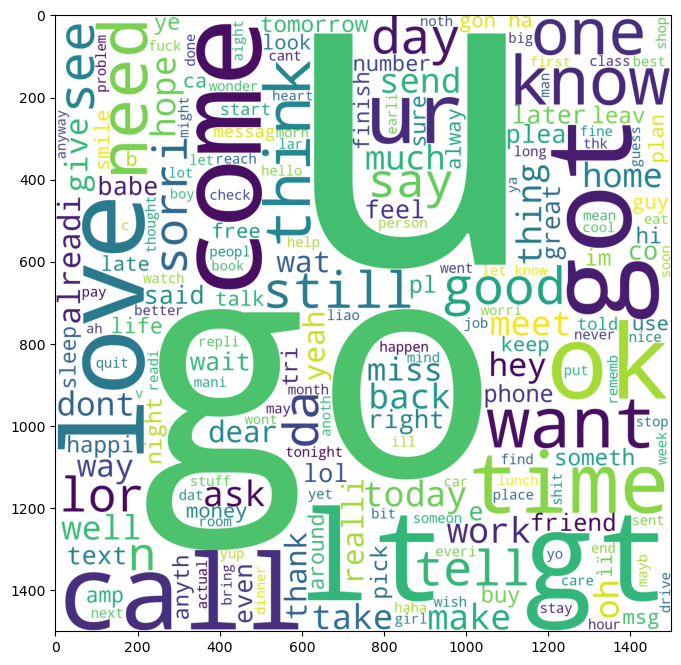

In [45]:
ham_wc = wc.generate(df[df['Target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(12,8))
plt.imshow(ham_wc)

In [46]:
df.head()

,Target,Text,Letter_count,Word_count,Sentence_count,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe usf live around though


In [47]:
spam_list = df[df['Target'] == 1]['transformed_text'].tolist()
# print(spam_list)

spam_corpus = []

for msg in spam_list:
    for word in msg.split():
        spam_corpus.append(word)

# print(spam_corpus)
print(f"Total number of words used in spam messages : {len(spam_corpus)}")


Total number of words used in spam messages : 9930


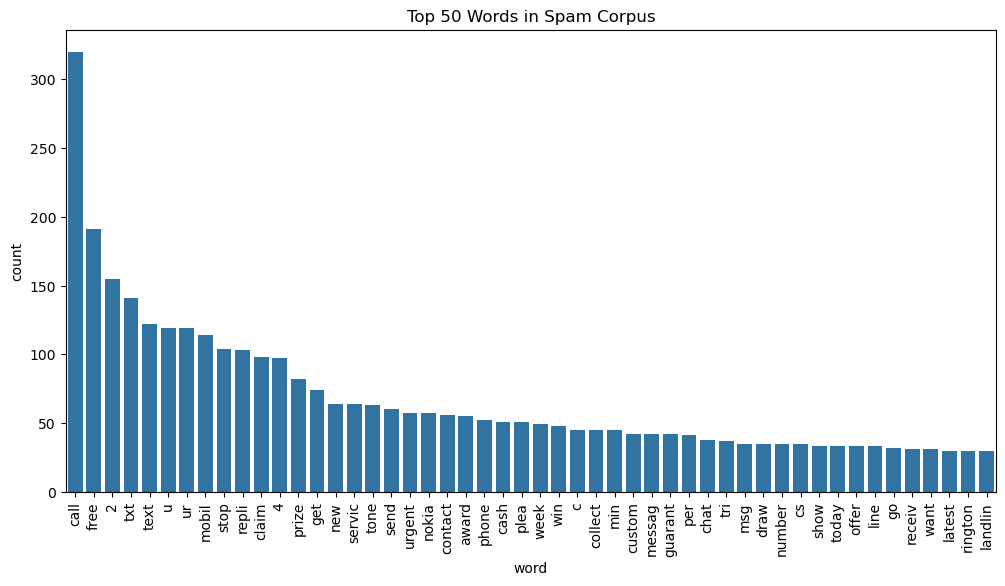

In [48]:
import seaborn as sns
from collections import Counter

spam_data_frame = pd.DataFrame(Counter(spam_corpus).most_common(50))
spam_data_frame.columns = ['word', 'count']  # rename columns

plt.figure(figsize=(12,6))
sns.barplot(data=spam_data_frame, x='word', y='count')
plt.xticks(rotation=90)
plt.title("Top 50 Words in Spam Corpus")
plt.show()


In [49]:
# Similar for ham messages

ham_list = df[df['Target'] == 0]['transformed_text'].tolist()

ham_corpus = []

for msg in ham_list:
    for word in msg.split():
        ham_corpus.append(word)

# print(ham_corpus)
print(f"Total number of words used in ham messages : {len(ham_corpus)}")


Total number of words used in ham messages : 35296


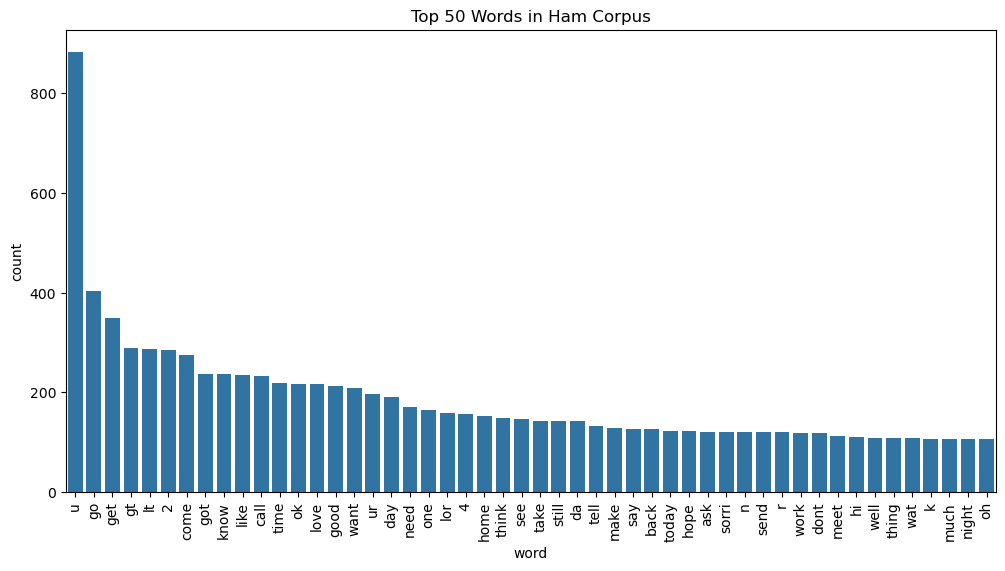

In [50]:
ham_data_frame = pd.DataFrame(Counter(ham_corpus).most_common(50))
ham_data_frame.columns = ['word', 'count']  # rename columns

plt.figure(figsize=(12,6))
sns.barplot(data=ham_data_frame, x='word', y='count')
plt.xticks(rotation=90)
plt.title("Top 50 Words in Ham Corpus")
plt.show()


In [51]:
spam_data_frame.head()

,word,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122


In [52]:
df.head()

,Target,Text,Letter_count,Word_count,Sentence_count,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe usf live around though


## 4. Model Building

In [53]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features= 4000)

In [54]:
x = tfidf.fit_transform(df['transformed_text']).toarray()
x.shape

# Here no of rows = no of msg = 5169
# No of unique features --> no of unique spam words = no of columns = 6672

(5169, 4000)

In [55]:
y = df['Target'].values
y.shape

# Here no of rows = no of msg = 5169
# No of unique features --> either 0 or 1 = no of columns = 1

(5169,)

In [56]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(4135, 4000) (1034, 4000)
(4135,) (1034,)


In [57]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



In [58]:
# """ 
# Accuracy : (TP+TN)/(TP+TN+FP+FN)
# Precision : TP/(TP+FP)
# Recall : TP/(TP+FN)
# """

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [60]:
lrc = LogisticRegression(C=1.0, max_iter=1000)
svc = SVC(C=1, kernel='linear', gamma='scale', probability=True)
dtc = DecisionTreeClassifier(max_depth=20, min_samples_split=5, criterion='entropy')
knc = KNeighborsClassifier()
gnb = GaussianNB()
mnb = MultinomialNB(alpha=0.5, fit_prior=True)
bnb = BernoulliNB(alpha=0.5, binarize=0.0, fit_prior=True)
rfc = RandomForestClassifier(
    n_estimators=200,       # Number of trees in the forest
    max_depth=20,           # Limit tree depth to prevent overfitting
    min_samples_split=5,    # Minimum samples required to split an internal node
    criterion='gini',       # Impurity measure ('gini' or 'entropy')
    random_state=2,         # Ensures reproducibility
    n_jobs=-1               # Uses all CPU cores for faster training
)

#### 1 - Logistic Regression

Training Accuracy = 0.9634824667472793
Test Accuracy = 0.9497098646034816
Precission Score = 0.9886363636363636
Recall Score = 0.6304347826086957
F1-Score      :0.7699115044247787
Confusion Matrix: (for test dataset)
 [[895   1]
 [ 51  87]]


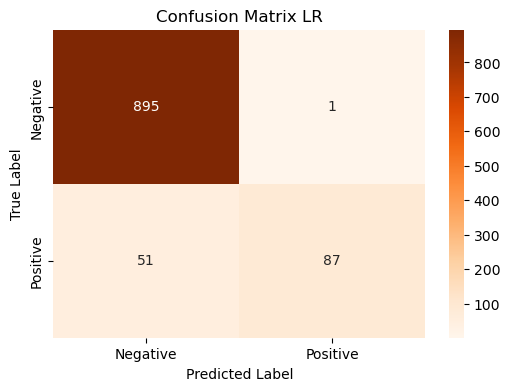

In [61]:
lrc.fit(x_train, y_train)     # Training the model
y_pred1_train = lrc.predict(x_train)
print(f"Training Accuracy = {accuracy_score(y_train, y_pred1_train)}")

y_pred1 = lrc.predict(x_test)
print(f"Test Accuracy = {accuracy_score(y_test, y_pred1)}")
print(f"Precission Score = {precision_score(y_test, y_pred1)}")
print(f"Recall Score = {recall_score(y_test, y_pred1)}")
print(f"F1-Score      :{f1_score(y_test, y_pred1)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred1))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix LR")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 2 - Support Vector Machine

Training Accuracy = 0.9912938331318016
Test Accuracy = 0.9787234042553191
Precission Score = 0.9754098360655737
Recall Score = 0.8623188405797102
F1-Score      :0.9153846153846154
Confusion Matrix: (for test dataset)
 [[893   3]
 [ 19 119]]


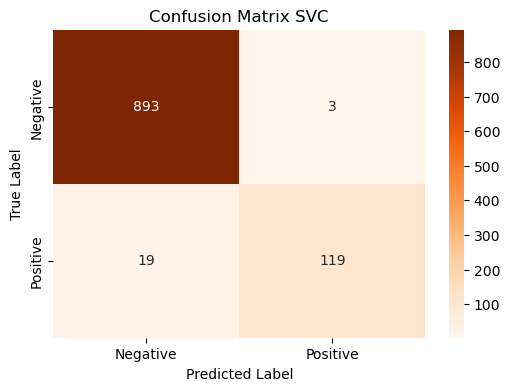

In [62]:
svc.fit(x_train, y_train)     # Training the model
y_pred2_train = svc.predict(x_train)
print(f"Training Accuracy = {accuracy_score(y_train, y_pred2_train)}")

y_pred2 = svc.predict(x_test)
print(f"Test Accuracy = {accuracy_score(y_test, y_pred2)}")
print(f"Precission Score = {precision_score(y_test, y_pred2)}")
print(f"Recall Score = {recall_score(y_test, y_pred2)}")
print(f"F1-Score      :{f1_score(y_test, y_pred2)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred2))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix SVC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 3 - Decision Tree Classifier

Training Accuracy = 0.9915356711003628
Test Accuracy = 0.960348162475822
Precission Score = 0.875968992248062
Recall Score = 0.8188405797101449
F1-Score      :0.846441947565543
Confusion Matrix: (for test dataset)
 [[880  16]
 [ 25 113]]


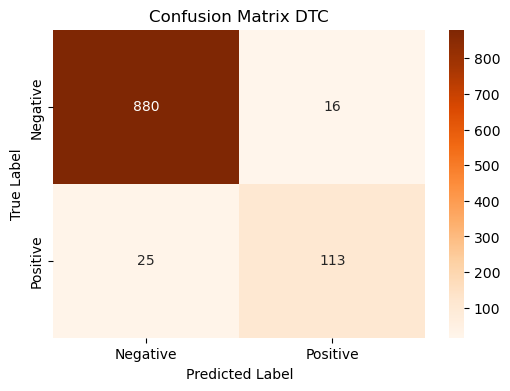

In [63]:
dtc.fit(x_train, y_train)     # Training the model
y_pred3_train = dtc.predict(x_train)
print(f"Training Accuracy = {accuracy_score(y_train, y_pred3_train)}")

y_pred3 = dtc.predict(x_test)
print(f"Test Accuracy = {accuracy_score(y_test, y_pred3)}")
print(f"Precission Score = {precision_score(y_test, y_pred3)}")
print(f"Recall Score = {recall_score(y_test, y_pred3)}")
print(f"F1-Score      :{f1_score(y_test, y_pred3)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred3))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix DTC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 4 - K-Neighbors Classifier

Training Accuracy = 0.9235792019347038
Test Accuracy = 0.9042553191489362
Precission Score = 1.0
Recall Score = 0.2826086956521739
F1-Score      :0.4406779661016949
Confusion Matrix: (for test dataset)
 [[896   0]
 [ 99  39]]


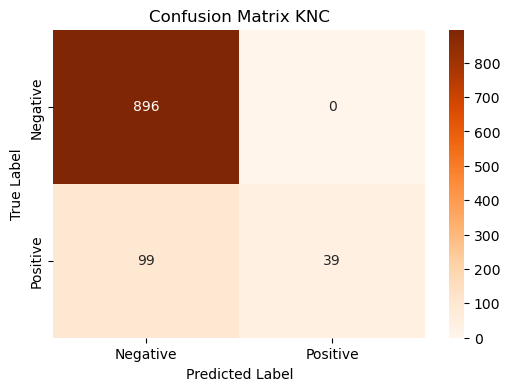

In [64]:
knc.fit(x_train, y_train)     # Training the model
y_pred4_train = knc.predict(x_train)
print(f"Training Accuracy = {accuracy_score(y_train, y_pred4_train)}")

y_pred4 = knc.predict(x_test)
print(f"Test Accuracy = {accuracy_score(y_test, y_pred4)}")
print(f"Precission Score = {precision_score(y_test, y_pred4)}")
print(f"Recall Score = {recall_score(y_test, y_pred4)}")
print(f"F1-Score      :{f1_score(y_test, y_pred4)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred4))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred4)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix KNC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 5 - Gaussian Naive Bayes

Train Accuracy : 0.9013301088270859
Test Accuracy  : 0.8762088974854932
Precision      : 0.5231481481481481
Recall         : 0.8188405797101449
F1-Score      :0.6384180790960452
Confusion Matrix: (for test dataset)
 [[793 103]
 [ 25 113]]


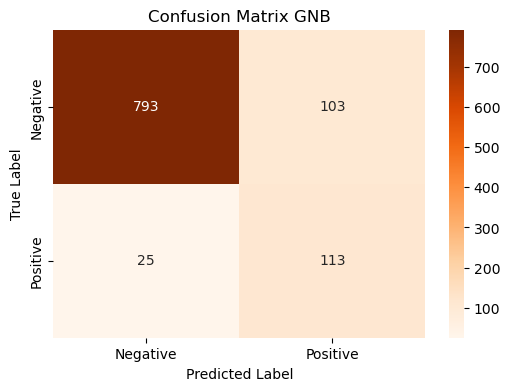

In [65]:
gnb.fit(x_train, y_train)    # Training the model
# Training accuracy
y_pred5_train = gnb.predict(x_train)   
print("Train Accuracy :", accuracy_score(y_train, y_pred5_train))

# Testing accuracy
y_pred5 = gnb.predict(x_test)
print("Test Accuracy  :", accuracy_score(y_test, y_pred5))
print("Precision      :", precision_score(y_test, y_pred5, zero_division=0))
print("Recall         :", recall_score(y_test, y_pred5))
print(f"F1-Score      :{f1_score(y_test, y_pred5)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred5)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix GNB")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 6 - Multinomial Naive Bayes

Train Accuracy : 0.9866989117291415
Test Accuracy  : 0.9787234042553191
Precision      : 1.0
Recall         : 0.8405797101449275
F1-Score      :0.9133858267716536
Confusion Matrix: (for test dataset)
 [[896   0]
 [ 22 116]]


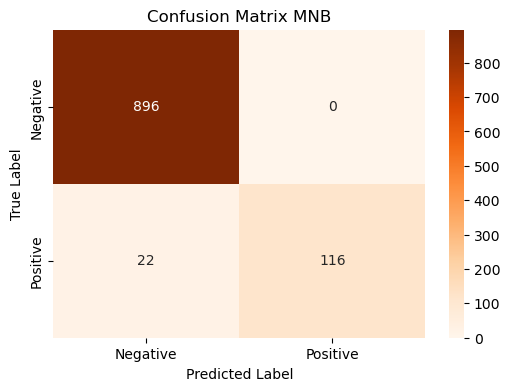

In [66]:
mnb.fit(x_train, y_train)    # Training the model
# Training accuracy
y_pred6_train = mnb.predict(x_train)   
print("Train Accuracy :", accuracy_score(y_train, y_pred6_train))

# Testing accuracy
y_pred6 = mnb.predict(x_test)
print("Test Accuracy  :", accuracy_score(y_test, y_pred6))
print("Precision      :", precision_score(y_test, y_pred6, zero_division=0))
print("Recall         :", recall_score(y_test, y_pred6))
print(f"F1-Score      :{f1_score(y_test, y_pred6)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred6))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred6)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix MNB")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 7 - Bernoulli's Naive Bayes

Train Accuracy : 0.9915356711003628
Test Accuracy  : 0.9864603481624759
Precision      : 0.984375
Recall         : 0.9130434782608695
F1-Score      :0.9473684210526315
Confusion Matrix: (for test dataset)
 [[894   2]
 [ 12 126]]


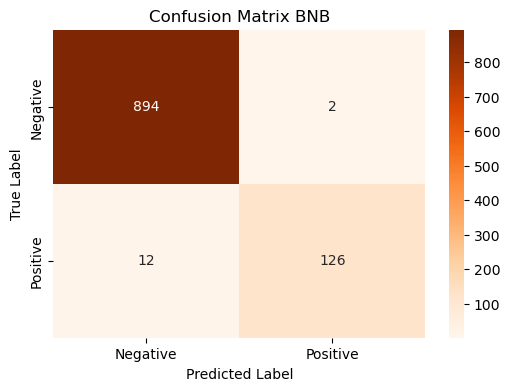

In [67]:
bnb.fit(x_train, y_train)    # Training the model
# Training accuracy
y_pred7_train = bnb.predict(x_train)   
print("Train Accuracy :", accuracy_score(y_train, y_pred7_train))

# Testing accuracy
y_pred7 = bnb.predict(x_test)
print("Test Accuracy  :", accuracy_score(y_test, y_pred7))
print("Precision      :", precision_score(y_test, y_pred7, zero_division=0))
print("Recall         :", recall_score(y_test, y_pred7))
print(f"F1-Score      :{f1_score(y_test, y_pred7)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred7))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred7)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix BNB")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### 8 - Random Forest Classifier

Train Accuracy : 0.9564691656590084
Test Accuracy  : 0.9439071566731141
Precision      : 1.0
Recall         : 0.5797101449275363
F1-Score      :0.7339449541284404
Confusion Matrix: (for test dataset)
 [[896   0]
 [ 58  80]]


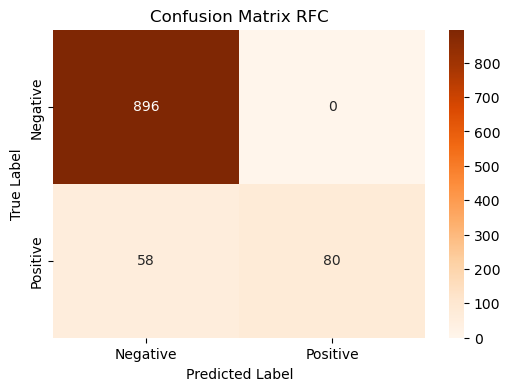

In [68]:
rfc.fit(x_train, y_train)    # Training the model
# Training accuracy
y_pred8_train = rfc.predict(x_train)   
print("Train Accuracy :", accuracy_score(y_train, y_pred8_train))

# Testing accuracy
y_pred8 = rfc.predict(x_test)
print("Test Accuracy  :", accuracy_score(y_test, y_pred8))
print("Precision      :", precision_score(y_test, y_pred8, zero_division=0))
print("Recall         :", recall_score(y_test, y_pred8))
print(f"F1-Score      :{f1_score(y_test, y_pred8)}")
print("Confusion Matrix: (for test dataset)\n", confusion_matrix(y_test, y_pred8))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred8)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title("Confusion Matrix RFC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

clfs = {
    'LR' : lrc,
    'SVC' : svc,
    'DT' : dtc,
    'KNN' : knc,
    'GNB' : gnb,
    'MNB' : mnb,
    'BNB' : bnb,
    'RF' : rfc,
}

def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)

    # Training accuracy
    y_pred_train = clf.predict(x_train)
    training_accuracy = accuracy_score(y_train, y_pred_train)
    
    # Test accuracy
    y_pred = clf.predict(x_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    return training_accuracy, test_accuracy, precision, recall, f1


# Lists to store results
training_accuracy_scores = []
test_accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
model_names = []

# Loop through each classifier
for name, clf in clfs.items():
    print(f"Training {name}...")
    train_acc, test_acc, prec, rec, f1 = train_classifier(clf, x_train, y_train, x_test, y_test)

    # Append to lists
    model_names.append(name)
    training_accuracy_scores.append(train_acc)
    test_accuracy_scores.append(test_acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)

print("------------------TRAINING COMPLETED------------------------")



Training LR...
Training SVC...
Training DT...
Training KNN...
Training GNB...
Training MNB...
Training BNB...
Training RF...
------------------TRAINING COMPLETED------------------------


In [70]:
# Create dataframe for visualization
results_df = pd.DataFrame({
    'Model': model_names,
    'Train Accuracy': training_accuracy_scores,
    'Test Accuracy': test_accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})
results_df = results_df.sort_values(by='F1-Score', ascending=False)
display(results_df)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
6,BNB,0.991536,0.986460,0.984375,0.913043,0.947368
1,SVC,0.991294,0.978723,0.975410,0.862319,0.915385
5,MNB,0.986699,0.978723,1.000000,0.840580,0.913386
2,DT,0.991294,0.954545,0.852713,0.797101,0.823970
0,LR,0.963482,0.949710,0.988636,0.630435,0.769912
7,RF,0.956469,0.943907,1.000000,0.579710,0.733945
4,GNB,0.901330,0.876209,0.523148,0.818841,0.638418
3,KNN,0.923579,0.904255,1.000000,0.282609,0.440678


/var/folders/by/4mx1q2s56g35znzytplgc89m0000gn/T/ipykernel_16642/3410435148.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df_melt, x='Model', y='Value', hue='Metric', ci=None)


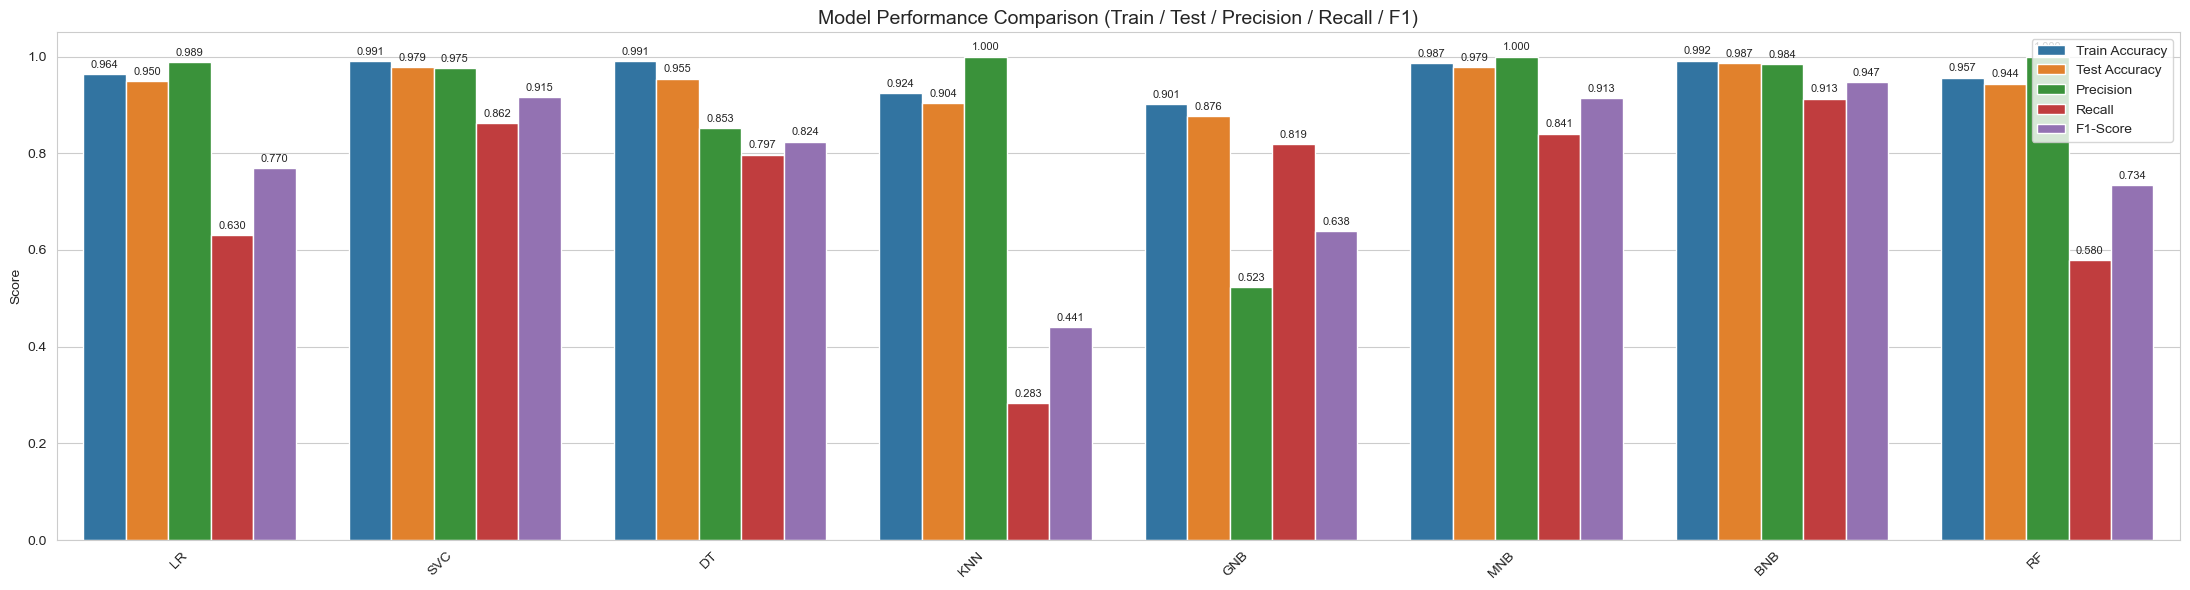

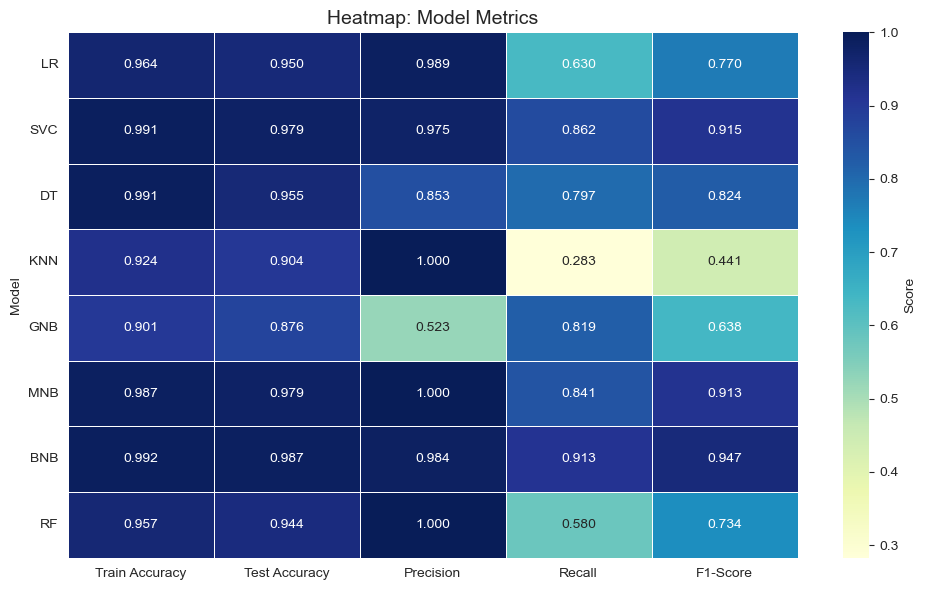

In [71]:
# corrected visualization cell
import matplotlib.pyplot as plt
import seaborn as sns

# --- Build dataframe (use your existing lists) ---
results_df = pd.DataFrame({
    'Model': model_names,
    'Train Accuracy': training_accuracy_scores,
    'Test Accuracy': test_accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

# Round for display
results_df = results_df.round(4)

# Re-order models as they appear (optional)
results_df = results_df.reset_index(drop=True)

# --- 1) Grouped bar chart (long form) ---
df_melt = results_df.melt(
    id_vars='Model',
    value_vars=['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(22,6))
sns.set_style("whitegrid")

# Draw grouped barplot
ax = sns.barplot(data=df_melt, x='Model', y='Value', hue='Metric', ci=None)

# Rotate x labels and tidy layout
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.title('Model Performance Comparison (Train / Test / Precision / Recall / F1)', fontsize=14)
plt.xlabel('')
plt.ylabel('Score')


# Annotate bars with values
for p in ax.patches:
    height = p.get_height()
    if height is not None and height > 0:
        ax.annotate(f'{height:.3f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                    textcoords='offset points')

plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=400)
plt.show()


# --- 2) Heatmap of metrics (models x metrics) ---
heat_df = results_df.set_index('Model')[['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']]

plt.figure(figsize=(10,6))
ax = sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label':'Score'}, linewidths=0.5)
plt.title('Heatmap: Model Metrics', fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('model_comparison_heatmap.png', dpi=300)
plt.show()


## 5. Model Improvement

In [72]:
'''
1 - Change the max_features parameter of TfIdf
'''


'\n1 - Change the max_features parameter of TfIdf\n'

In [ ]:
# # --- Predict Spam or Ham for a New Message ---

# # Ask user for input message
# input_msg = input("Enter a new message: ")

# # Step 1: Preprocess the message using the same text transformation
# processed_msg = transform_text(input_msg)
# # print(processed_msg)

# # Step 2: Convert text to vector using your TF-IDF vectorizer
# vector_input = tfidf.transform([processed_msg])
# # print(vector_input)

# # Step 3: Predict using your trained model (choose your best one, e.g., bnb or rfc)
# prediction = bnb.predict(vector_input)[0]   

# # Step 4: Print result
# if prediction == 1:
#     print("The message is SPAM!")
# else:
#     print("The message is HAM.")


The message is HAM.


In [75]:
import pickle

with open ('model.pkl', 'wb') as file:
    pickle.dump(bnb, file)

In [76]:
import pickle

with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)
